In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')


In [ ]:
df = pd.read_csv("exams.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,67,67,63
1,female,group D,some high school,free/reduced,none,40,59,55
2,male,group E,some college,free/reduced,none,59,60,50
3,male,group B,high school,standard,none,77,78,68
4,male,group E,associate's degree,standard,completed,78,73,68


In [ ]:
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [ ]:
df.isna()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False


In [ ]:
df.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
df2 = df.copy()
df2.loc[0:5, 'math score'] = np.nan
df2.isna().sum()


,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,6
reading score,0
writing score,0


In [ ]:
df2.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,NaN,67,63
1,female,group D,some high school,free/reduced,none,NaN,59,55
2,male,group E,some college,free/reduced,none,NaN,60,50
3,male,group B,high school,standard,none,NaN,78,68
4,male,group E,associate's degree,standard,completed,NaN,73,68
5,female,group D,high school,standard,none,NaN,77,76
6,female,group A,bachelor's degree,standard,none,62.0,59,63
7,male,group E,some college,standard,completed,93.0,88,84
8,male,group D,high school,standard,none,63.0,56,65
9,male,group C,some college,free/reduced,none,47.0,42,45


In [ ]:
df_remove = df2.dropna()
print('df with NaN: ',df2.shape)
print('df without NaN: ',df_remove.shape)

df with NaN:  (1000, 8)
df without NaN:  (994, 8)


In [ ]:
df_remove.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [37]:
df_mean = df2.copy()
df_mean['math score'] = df_mean['math score'].fillna(df_mean['math score'].mean())

In [38]:
df_mean.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,66.5,67,63
1,female,group D,some high school,free/reduced,none,66.5,59,55
2,male,group E,some college,free/reduced,none,66.5,60,50
3,male,group B,high school,standard,none,66.5,78,68
4,male,group E,associate's degree,standard,completed,66.5,73,68
5,female,group D,high school,standard,none,66.5,77,76
6,female,group A,bachelor's degree,standard,none,62.0,59,63
7,male,group E,some college,standard,completed,93.0,88,84
8,male,group D,high school,standard,none,63.0,56,65
9,male,group C,some college,free/reduced,none,47.0,42,45


In [ ]:
df_median = df2.copy()
df_median['math score'] = df_median['math score'].fillna(df_median['math score'].median())


In [ ]:
df_median.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,66.5,67,63
1,female,group D,some high school,free/reduced,none,66.5,59,55
2,male,group E,some college,free/reduced,none,66.5,60,50
3,male,group B,high school,standard,none,66.5,78,68
4,male,group E,associate's degree,standard,completed,66.5,73,68
5,female,group D,high school,standard,none,66.5,77,76
6,female,group A,bachelor's degree,standard,none,62.0,59,63
7,male,group E,some college,standard,completed,93.0,88,84
8,male,group D,high school,standard,none,63.0,56,65
9,male,group C,some college,free/reduced,none,47.0,42,45


In [ ]:
import matplotlib.pyplot as plt


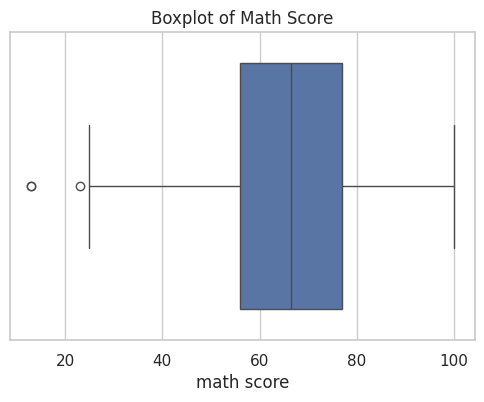

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['math score'])

plt.title('Boxplot of Math Score')
plt.show()


In [ ]:
Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['math score'] < lower) | (df['math score'] > upper)]
outliers.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
18,female,group C,associate's degree,free/reduced,none,23,44,44
392,female,group C,some college,free/reduced,none,13,29,23
832,female,group D,some college,free/reduced,none,13,36,37


In [ ]:
df_no_outliers = df[(df['math score'] >= lower) & (df['math score'] <= upper)]

print('df with outliers: ', df.shape)
print('df without outliers: ', df_no_outliers.shape)


df with outliers:  (1000, 8)
df without outliers:  (997, 8)


In [ ]:
lower_cap = df['math score'].quantile(0.05)
upper_cap = df['math score'].quantile(0.95)

df_capped = df.copy()
df_capped['math score'] = df_capped['math score'].clip(lower_cap, upper_cap)


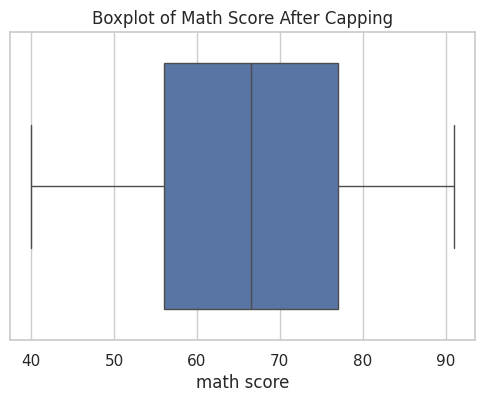

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_capped['math score'])

plt.title('Boxplot of Math Score After Capping')
plt.show()


In [ ]:
df[['math score', 'reading score', 'writing score']].head()

,math score,reading score,writing score
0,67,67,63
1,40,59,55
2,59,60,50
3,77,78,68
4,78,73,68


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['math score', 'reading score', 'writing score']].copy()

df_scaled[['math score', 'reading score', 'writing score']] = scaler.fit_transform(df_scaled)

df_scaled.head()


,math score,reading score,writing score
0,0.620690,0.547945,0.519481
1,0.310345,0.438356,0.415584
2,0.528736,0.452055,0.350649
3,0.735632,0.698630,0.584416
4,0.747126,0.630137,0.584416


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['math score', 'reading score', 'writing score']].copy()

df_standardized[['math score', 'reading score', 'writing score']] = scaler.fit_transform(df_standardized)

df_standardized.head()


,math score,reading score,writing score
0,0.039233,-0.135914,-0.303851
1,-1.714564,-0.679027,-0.816895
2,-0.480410,-0.611138,-1.137548
3,0.688788,0.610866,0.016802
4,0.753743,0.271421,0.016802


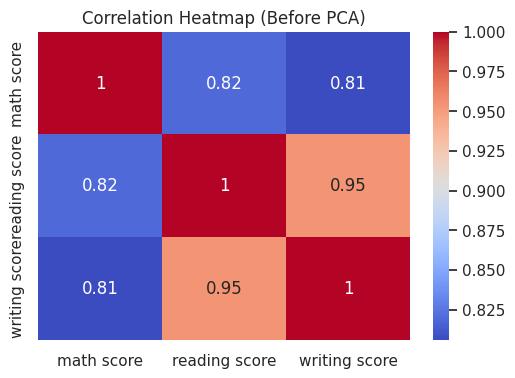

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['math score','reading score','writing score']].corr(),
            annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap (Before PCA)")
plt.show()


In [ ]:
from sklearn.decomposition import PCA

X = df_standardized[['math score', 'reading score', 'writing score']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.90718213 0.07769086]


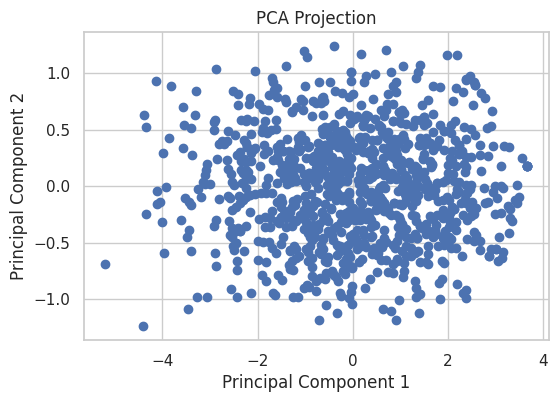

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()